# CMS Open Data Analysis Tutorial

This tutorial guides you through the process of searching CMS Open Data, understanding experimental metadata, setting up an efficient analysis pipeline, and executing a columnar analysis using Python.

---

## Phase 1: Planning Your Analysis

Before downloading data from the CERN Open Data Portal, define your target experimental parameters:
* **Data-Taking Period**: Choose between **Run 1** (2010–2012, 7–8 TeV) or **Run 2** (2015–2018, 13 TeV).
* **Primary Dataset**: Locate the collision dataset matching your target final-state objects (e.g., `SingleElectron`, `DoubleMuon`, `JetHT`).
* **Monte Carlo (MC) Datasets**: Identify simulated samples for your target **signal** and standard physics **backgrounds**.
* **Data Provenance**: Note the dataset **DOI** for reference and scientific reproducibility.

## Phase 2: Workflow Architecture

CMS open data analyses generally utilize a two-step framework:

```
[ Primary Dataset / AOD ] ---> ( CMSSW Processing / Step 1 ) ---> [ NanoAOD / Ntuple ]
                                                                       |
[ Scientific Python Environment ] <--- ( Columnar Analysis / Step 2 ) <--+
```

| Pipeline Stage | Framework | Format | Description |
| :--- | :--- | :--- | :--- |
| **Step 1: Data Reduction** | CMSSW (CVMFS/Docker) | AOD / MiniAOD | Filter raw events, apply object calibrations, and export flat tuples. |
| **Step 2: Interactive Analysis** | Python (Uproot, Awkward) | NanoAOD / ROOT | Perform cuts, reconstruct invariant masses, and generate final histograms. |

## Phase 3: Hands-On Columnar Analysis in Python

In this section, we process lightweight **NanoAOD** event data to reconstruct the $Z \rightarrow e^+e^-$ invariant mass peak.

# Reconstructing $Z \rightarrow e^+e^-$ Invariant Mass

This section processes high-energy physics event data using `uproot`, `awkward`, and `vector` to inspect collision events, apply kinematic cuts, and plot the invariant mass distribution of dielectron candidates.

In [ ]:
# Install dependencies if running in a new environment
# !pip install numpy uproot awkward vector matplotlib

In [4]:
import numpy as np
import uproot
import awkward as ak
import vector
import matplotlib.pyplot as plt

# Register vector behavior with awkward array
vector.register_awkward()
print("Executed Successfuly ...")

Executed Successfuly


## 1. Load Data & Filter Electron Collections

In [5]:
file = uproot.open("sample.root")
tree = file["Events"]

# Load required branches into Awkward Arrays
branches = tree.arrays([
    "Electron_pt", "Electron_eta", "Electron_phi", 
    "Electron_mass", "Electron_charge"
], library="ak")

# Kinematic cuts: pT > 25 GeV, |eta| < 2.5 (excluding ECAL gap)
good_electrons_mask = (
    (branches.Electron_pt > 25.0) & 
    (abs(branches.Electron_eta) < 2.5) & 
    ((abs(branches.Electron_eta) < 1.4442) | (abs(branches.Electron_eta) > 1.566))
)

# Apply mask at collection level
good_electrons = branches[good_electrons_mask]

# Keep events with at least 2 good electrons
selected_events = good_electrons[ak.num(good_electrons.Electron_pt) >= 2]

print("Executed Successfuly ...")

Executed Successfuly ...


## 2. Construct 4-Vectors & Calculate Invariant Mass

In [6]:
electrons = ak.zip({
    "pt": selected_events.Electron_pt,
    "eta": selected_events.Electron_eta,
    "phi": selected_events.Electron_phi,
    "mass": selected_events.Electron_mass,
    "charge": selected_events.Electron_charge
}, with_name="Momentum4D")

# Select leading and subleading electrons
e1 = electrons[:, 0]
e2 = electrons[:, 1]

# Opposite-sign requirement
os_cut = (e1.charge != e2.charge)

# Reconstruct invariant mass and convert to 1D NumPy array
z_mass_ak = (e1[os_cut] + e2[os_cut]).mass
z_mass = ak.to_numpy(ak.flatten(z_mass_ak, axis=None))

# Apply signal window filter (60–120 GeV)
mass_min, mass_max = 60.0, 120.0
in_range_mask = (z_mass >= mass_min) & (z_mass <= mass_max)
z_mass_window = z_mass[in_range_mask]

# Compute statistics
entries = len(z_mass_window)
mean = np.mean(z_mass_window)
std = np.std(z_mass_window)
median = np.median(z_mass_window)

print("Executed Successfuly ...")

Executed Successfuly ...


## 3. Plot Invariant Mass Spectrum

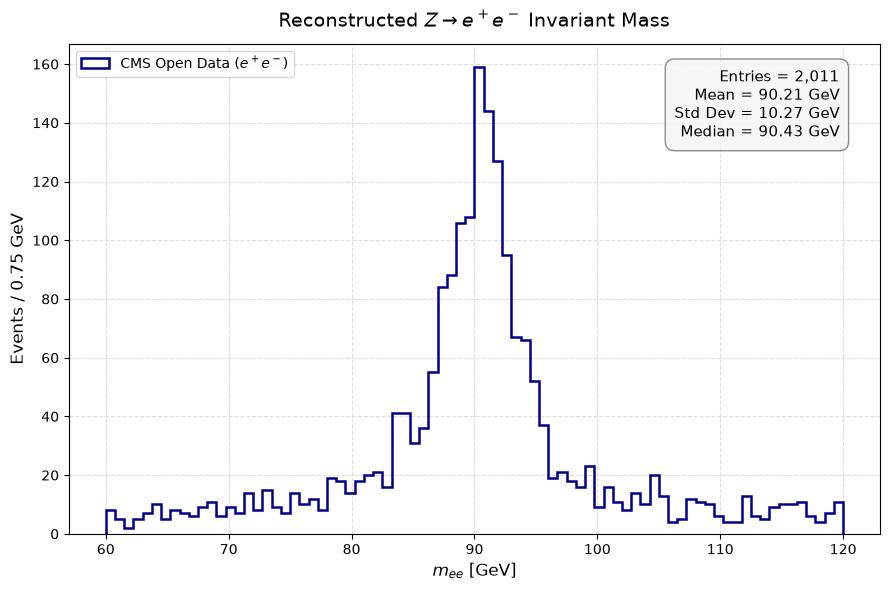

In [7]:
plt.figure(figsize=(9, 6))

# Plot histogram
counts, bins, patches = plt.hist(
    z_mass_window, 
    bins=80, 
    range=(mass_min, mass_max), 
    histtype='step', 
    color='darkblue', 
    linewidth=1.8,
    label=r"CMS Open Data ($e^+e^-$)"
)

# Format statistics text box
stats_text = (
    f"Entries = {entries:,}\n"
    f"Mean = {mean:.2f} GeV\n"
    f"Std Dev = {std:.2f} GeV\n"
    f"Median = {median:.2f} GeV"
)

# Render text box
plt.gca().text(
    0.95, 0.95, stats_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='whitesmoke', edgecolor='gray', alpha=0.9)
)

plt.xlabel(r"$m_{ee}$ [GeV]", fontsize=12)
plt.ylabel(f"Events / {(mass_max - mass_min) / 80:.2f} GeV", fontsize=12)
plt.title(r"Reconstructed $Z \rightarrow e^+e^-$ Invariant Mass", fontsize=14, pad=12)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show()

## Phase 4: Data Quality & Luminosity Corrections

To bring an analysis up to research quality:
* **JSON Good Run Lists**: Filter out runs or luminosity sections that failed detector quality validation using JSON files supplied on the portal.
* **Luminosity Calculation**: Look up CSV luminosity records per luminosity section to calculate total integrated luminosity ($\mathcal{L}$) for cross-section calculations.
* **Condition Database**: Fetch non-event calibration data (e.g., Jet Energy Corrections) via CVMFS.